## **Case Study: Ad Targeting Optimization**
# Problem statement:

A digital advertising company aims to significantly improve its ad targeting efficiency. Currently, ads are displayed indiscriminately to all users, resulting in suboptimal engagement and a low overall Click-Through Rate (CTR).

The company has provided a dataset containing demographic and contextual data for users who were shown ads.

Your task is to build an Unsupervised Learning system to discover hidden user segments that behave similarly. These robust, data-driven user groups will be used to implement highly focused ad targeting strategies.

Dataset link: https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/169/383/original/ad_click_dataset.csv?1764943571

Dataset description: Dataset Description.docx

Approach document: Refer to the document below to help guide you in solving the questions.

https://docs.google.com/document/d/1KeoLKH4oUnCCp7c_2S0dHKOwUGh8CcmdLhR0Pio5474/edit?tab=t.0

In [1]:
"""
=========================================================
Ad Targeting Optimization using Unsupervised Learning
=========================================================

Objective:
Discover hidden customer segments using clustering so that
the advertising company can allocate marketing budget
towards users with the highest Click Through Rate (CTR).

Models:
1. KMeans
2. Autoencoder + KMeans

Evaluation:
• Silhouette Score
• Davies Bouldin Index
• Calinski Harabasz Score
• Cluster-wise CTR
• Business Recommendations
"""

'\n=========================================================\nAd Targeting Optimization using Unsupervised Learning\n=========================================================\n\nObjective:\nDiscover hidden customer segments using clustering so that\nthe advertising company can allocate marketing budget\ntowards users with the highest Click Through Rate (CTR).\n\nModels:\n1. KMeans\n2. Autoencoder + KMeans\n\nEvaluation:\n• Silhouette Score\n• Davies Bouldin Index\n• Calinski Harabasz Score\n• Cluster-wise CTR\n• Business Recommendations\n'

2. Install Libraries

In [2]:
!pip install -q yellowbrick kneed tensorflow

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

from yellowbrick.cluster import KElbowVisualizer

from sklearn.neighbors import NearestNeighbors

import tensorflow as tf
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.models import Model

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(8,5)

RANDOM_STATE=42

4. Load Dataset

In [4]:
from google.colab import files

uploaded=files.upload()

filename=list(uploaded.keys())[0]

df=pd.read_csv(filename)

df.head()

Saving ad_click_dataset.csv to ad_click_dataset.csv


,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
0,670,User670,22.0,NaN,Desktop,Top,Shopping,Afternoon,1
1,3044,User3044,NaN,Male,Desktop,Top,NaN,NaN,1
2,5912,User5912,41.0,Non-Binary,NaN,Side,Education,Night,1
3,5418,User5418,34.0,Male,NaN,NaN,Entertainment,Evening,1
4,9452,User9452,39.0,Non-Binary,NaN,NaN,Social Media,Morning,0


In [5]:
print("="*50)

print(df.shape)

print("="*50)

df.info()

print("="*50)

display(df.describe(include="all"))

print("="*50)

print(df.isnull().sum())

(10000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                10000 non-null  int64  
 1   full_name         10000 non-null  object 
 2   age               5234 non-null   float64
 3   gender            5307 non-null   object 
 4   device_type       8000 non-null   object 
 5   ad_position       8000 non-null   object 
 6   browsing_history  5218 non-null   object 
 7   time_of_day       8000 non-null   object 
 8   click             10000 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 703.3+ KB


,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
count,10000.000000,10000,5234.000000,5307,8000,8000,5218,8000,10000.000000
unique,NaN,4000,NaN,3,3,3,5,4,NaN
top,NaN,User1171,NaN,Female,Desktop,Bottom,Entertainment,Morning,NaN
freq,NaN,25,NaN,1834,2754,2817,1175,2126,NaN
mean,5060.211400,NaN,40.197363,NaN,NaN,NaN,NaN,NaN,0.650000
std,2861.758265,NaN,13.126420,NaN,NaN,NaN,NaN,NaN,0.476993
min,5.000000,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,2529.000000,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,5218.000000,NaN,39.500000,NaN,NaN,NaN,NaN,NaN,1.000000
75%,7466.000000,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,1.000000


id                     0
full_name              0
age                 4766
gender              4693
device_type         2000
ad_position         2000
browsing_history    4782
time_of_day         2000
click                  0
dtype: int64


In [6]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 2853


In [7]:
df=df.drop(columns=["id","full_name"])

df.head()

,age,gender,device_type,ad_position,browsing_history,time_of_day,click
0,22.0,NaN,Desktop,Top,Shopping,Afternoon,1
1,NaN,Male,Desktop,Top,NaN,NaN,1
2,41.0,Non-Binary,NaN,Side,Education,Night,1
3,34.0,Male,NaN,NaN,Entertainment,Evening,1
4,39.0,Non-Binary,NaN,NaN,Social Media,Morning,0


In [8]:
categorical=df.select_dtypes(include="object").columns

numerical=df.select_dtypes(exclude="object").columns

categorical

Index(['gender', 'device_type', 'ad_position', 'browsing_history',
       'time_of_day'],
      dtype='object')

In [9]:
for col in categorical:

    df[col]=df[col].fillna(df[col].mode()[0])

for col in numerical:

    df[col]=df[col].fillna(df[col].median())

In [10]:
df.isnull().sum()

,0
age,0
gender,0
device_type,0
ad_position,0
browsing_history,0
time_of_day,0
click,0


10. Numerical Feature Distribution

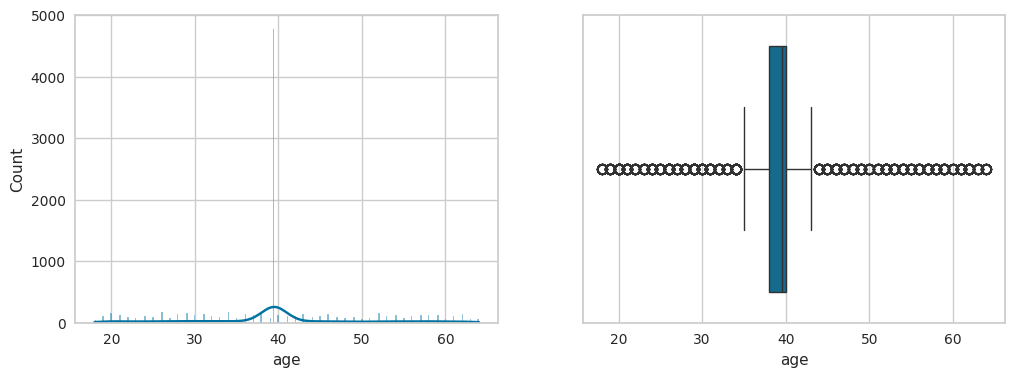

In [11]:
fig,ax=plt.subplots(1,2,figsize=(12,4))

sns.histplot(df["age"],kde=True,ax=ax[0])

sns.boxplot(x=df["age"],ax=ax[1])

plt.show()

11. Target Distribution

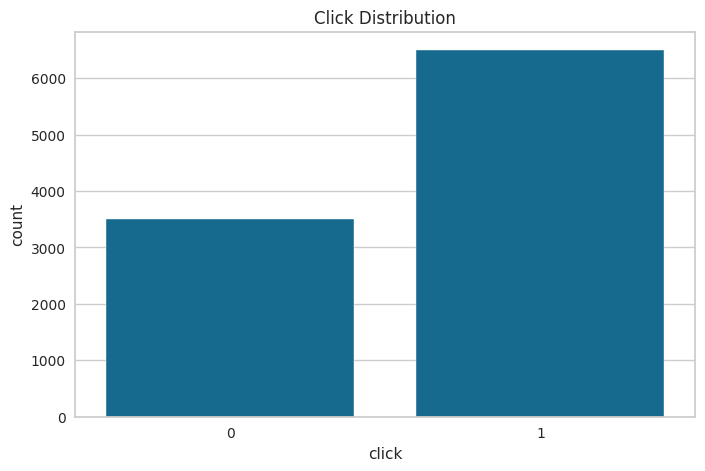

click
1    0.65
0    0.35
Name: proportion, dtype: float64


In [12]:
sns.countplot(data=df,x="click")

plt.title("Click Distribution")

plt.show()

print(df["click"].value_counts(normalize=True))

12. Age vs Click

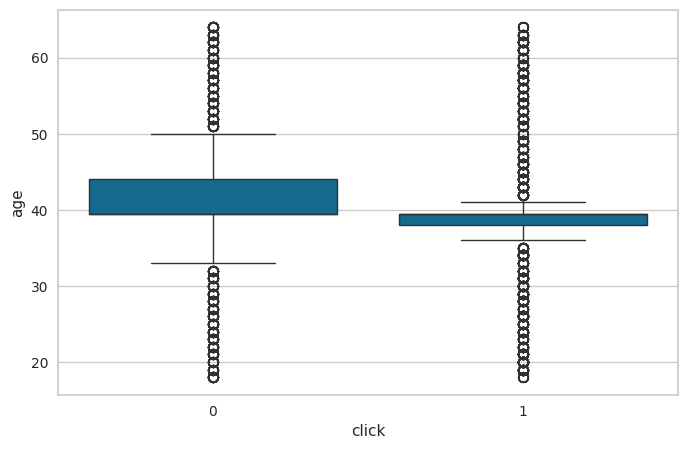

In [13]:
sns.boxplot(
    data=df,
    x="click",
    y="age"
)

plt.show()

13. Gender Distribution

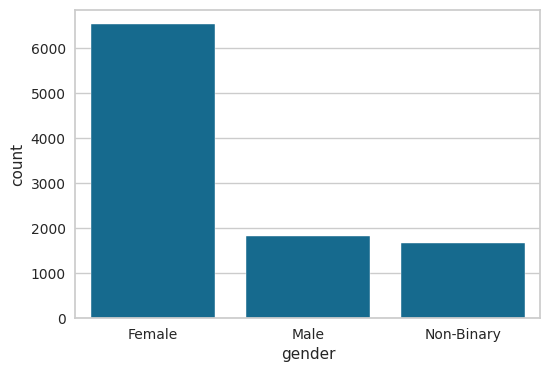

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="gender")

plt.show()

14. Device Distribution

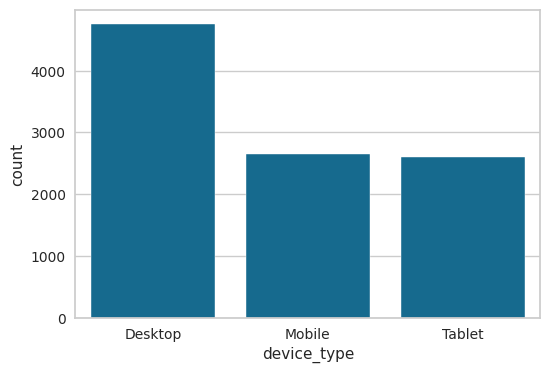

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="device_type")

plt.show()

15. Browsing History

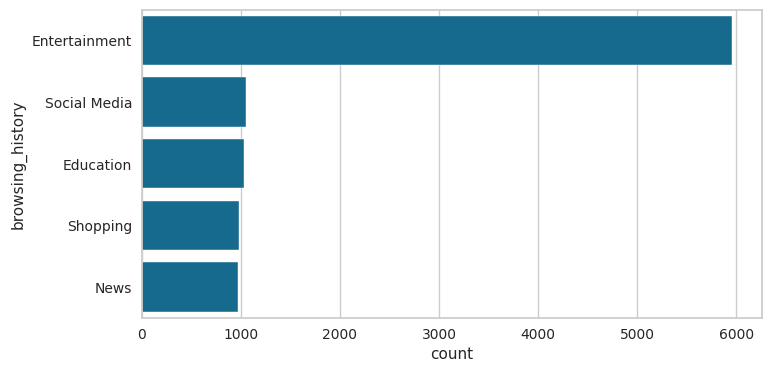

In [16]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    y="browsing_history",
    order=df["browsing_history"].value_counts().index
)

plt.show()

16. Time of Day

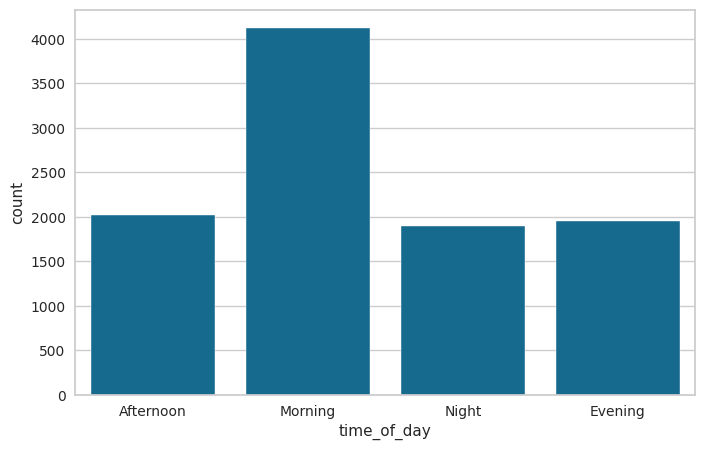

In [17]:
sns.countplot(
    data=df,
    x="time_of_day"
)

plt.show()

17. Ad Position

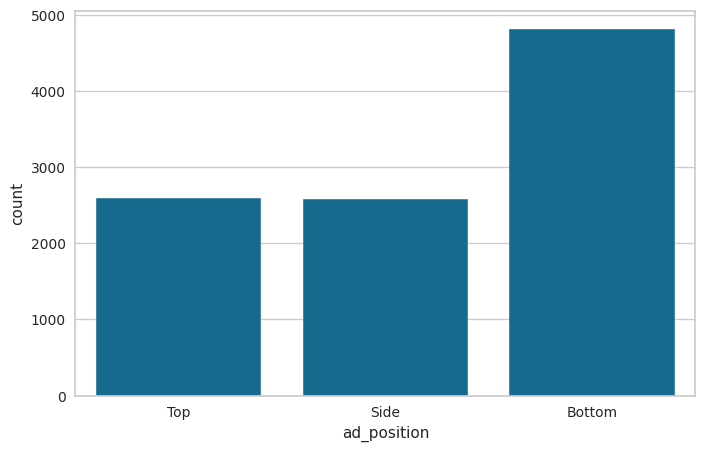

In [18]:
sns.countplot(
    data=df,
    x="ad_position"
)

plt.show()

18. CTR by Device

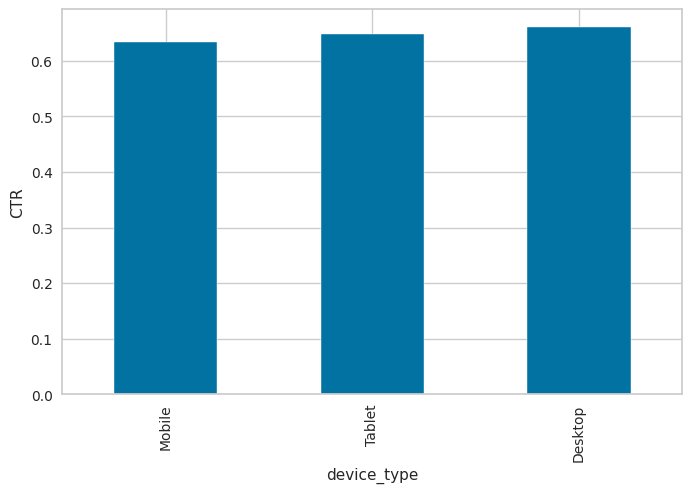

In [19]:
ctr=df.groupby("device_type")["click"].mean().sort_values()

ctr.plot(kind="bar")

plt.ylabel("CTR")

plt.show()

19. CTR by Browsing Category

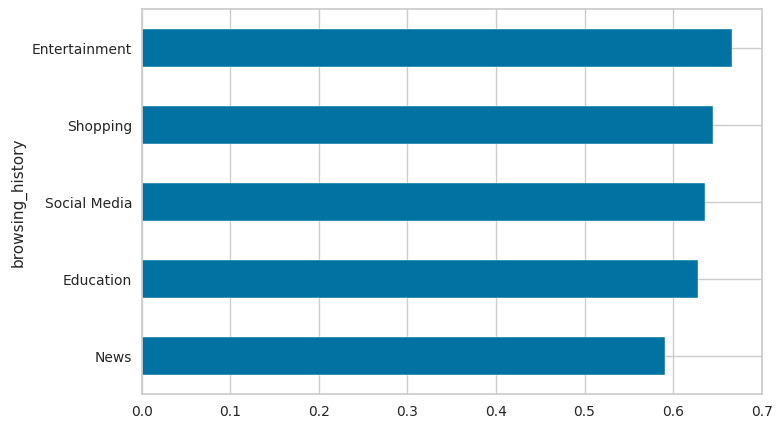

In [20]:
ctr=df.groupby("browsing_history")["click"].mean().sort_values()

ctr.plot(kind="barh")

plt.show()

20. CTR by Time

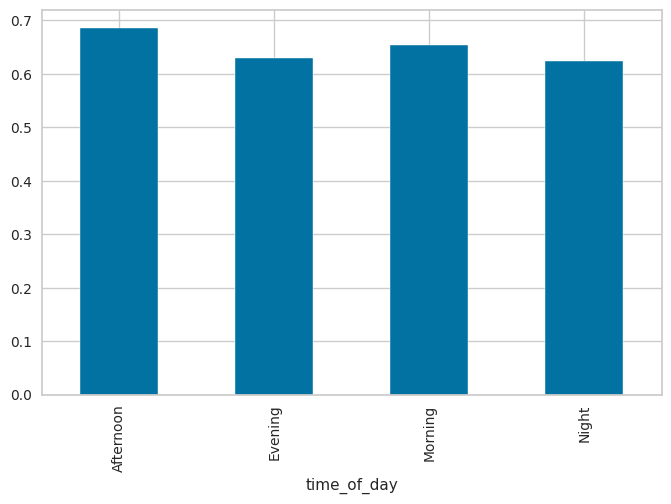

In [21]:
ctr=df.groupby("time_of_day")["click"].mean()

ctr.plot(kind="bar")

plt.show()

21. CTR by Gender

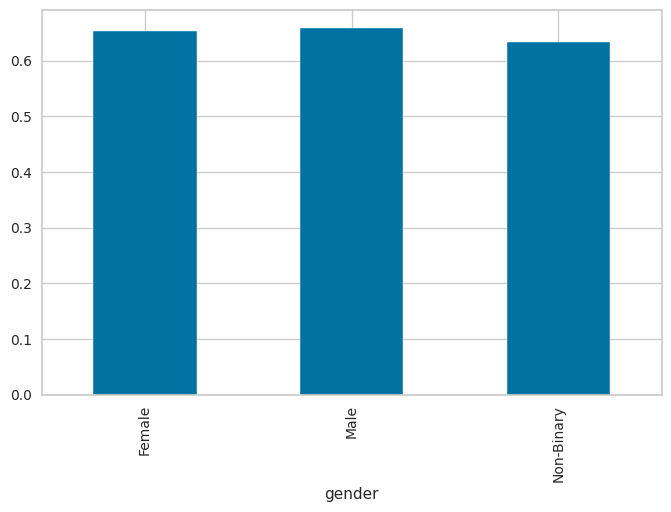

In [22]:
ctr=df.groupby("gender")["click"].mean()

ctr.plot(kind="bar")

plt.show()

22. Pairplot

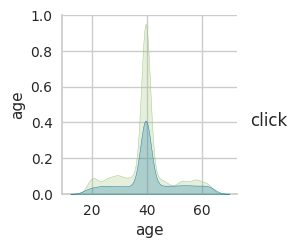

In [23]:
sns.pairplot(
    df,
    vars=["age"],
    hue="click"
)

23. Correlation Matrix

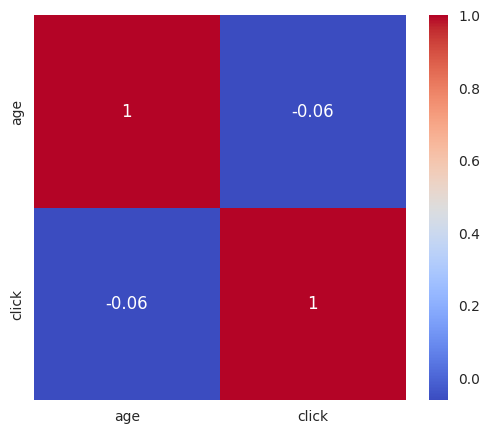

In [24]:
corr=df.corr(numeric_only=True)

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

24. Feature Engineering

In [25]:
df["is_mobile_user"]=(df["device_type"]=="Mobile").astype(int)

25. Final Dataset Preview

In [26]:
df.head()

,age,gender,device_type,ad_position,browsing_history,time_of_day,click,is_mobile_user
0,22.0,Female,Desktop,Top,Shopping,Afternoon,1,0
1,39.5,Male,Desktop,Top,Entertainment,Morning,1,0
2,41.0,Non-Binary,Desktop,Side,Education,Night,1,0
3,34.0,Male,Desktop,Bottom,Entertainment,Evening,1,0
4,39.0,Non-Binary,Desktop,Bottom,Social Media,Morning,0,0


26. Separate Features and Target

In [27]:
# Keep click only for business evaluation
target = df["click"]

X = df.drop(columns=["click"])

print("Feature Shape :", X.shape)

Feature Shape : (10000, 7)


27. Identify Numerical & Categorical Columns

In [28]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features")
print(categorical_cols)

print("\nNumerical Features")
print(numerical_cols)

Categorical Features
['gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day']

Numerical Features
['age', 'is_mobile_user']



28. One-Hot Encode Categorical Variables

In [29]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print(X_encoded.shape)

X_encoded.head()

(10000, 15)


,age,is_mobile_user,gender_Male,gender_Non-Binary,device_type_Mobile,device_type_Tablet,ad_position_Side,ad_position_Top,browsing_history_Entertainment,browsing_history_News,browsing_history_Shopping,browsing_history_Social Media,time_of_day_Evening,time_of_day_Morning,time_of_day_Night
0,22.0,0,False,False,False,False,False,True,False,False,True,False,False,False,False
1,39.5,0,True,False,False,False,False,True,True,False,False,False,False,True,False
2,41.0,0,False,True,False,False,True,False,False,False,False,False,False,False,True
3,34.0,0,True,False,False,False,False,False,True,False,False,False,True,False,False
4,39.0,0,False,True,False,False,False,False,False,False,False,True,False,True,False


29. Standard Scaling

In [30]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

print(X_scaled.shape)

(10000, 15)


30. PCA (All Components)

In [31]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_

cum_var = np.cumsum(explained)

31. Explained Variance Plot

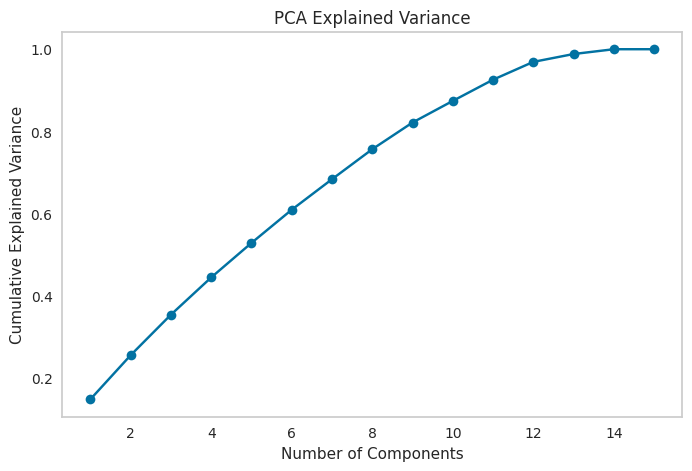

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(cum_var)+1),
    cum_var,
    marker="o"
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid()

plt.show()

32. Choose Components (95%)

In [33]:
n_components = np.argmax(cum_var>=0.95)+1

print("Optimal Components :",n_components)

Optimal Components : 12


33. Fit Final PCA

In [34]:
pca = PCA(n_components=n_components,random_state=42)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(10000, 12)


34. PCA Loadings

In [35]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(n_components)],
    index=X_encoded.columns
)

display(loadings.head(20))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
age,-0.038472,-0.094411,-0.051569,-0.110689,0.119779,0.094300,-0.232470,-0.108505,0.935847,-0.005076,-0.096497,0.000129
is_mobile_user,0.643468,0.056207,0.028623,-0.042729,0.031691,-0.043916,0.053959,-0.000328,0.067298,0.120803,0.234790,0.003999
gender_Male,-0.022600,-0.039130,-0.119827,-0.026692,-0.414106,-0.469793,-0.030743,-0.302577,0.018336,0.643385,-0.282054,0.051572
gender_Non-Binary,0.035686,-0.023189,0.034210,0.020722,0.409338,0.513514,0.034864,0.244688,-0.096019,0.611982,-0.346934,0.009872
device_type_Mobile,0.643468,0.056207,0.028623,-0.042729,0.031691,-0.043916,0.053959,-0.000328,0.067298,0.120803,0.234790,0.003999
device_type_Tablet,-0.378956,-0.048767,0.013506,-0.035890,0.104878,0.063954,0.034619,-0.106541,0.038600,0.404046,0.812209,0.005075
ad_position_Side,-0.021237,-0.072416,0.054962,-0.677833,-0.107614,0.087896,0.056954,0.084263,-0.056991,-0.045763,-0.008401,0.703836
ad_position_Top,0.014916,0.061333,-0.065954,0.678780,0.134003,-0.081031,-0.040539,-0.024595,0.064728,-0.012742,0.028585,0.705514
browsing_history_Entertainment,-0.077848,0.736700,0.135755,-0.057721,-0.032206,0.016565,-0.022923,-0.012349,0.057948,0.041037,-0.026769,0.040804
browsing_history_News,0.028996,-0.348385,-0.105662,0.067990,-0.013975,0.209231,0.672277,-0.404295,0.057327,-0.079489,-0.068232,0.023182


35. Elbow Method

In [36]:
sse=[]

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_pca)

    sse.append(model.inertia_)

36. Plot Elbow Curve

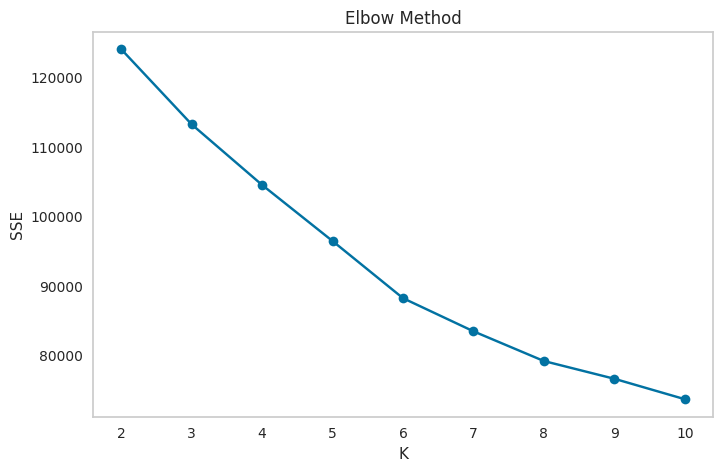

In [37]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    sse,
    marker="o"
)

plt.xlabel("K")

plt.ylabel("SSE")

plt.title("Elbow Method")

plt.grid()

plt.show()

37. Silhouette Score

In [38]:
scores=[]

for k in range(2,11):

    km=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels=km.fit_predict(X_pca)

    scores.append(
        silhouette_score(
            X_pca,
            labels
        )
    )

38. Plot Silhouette

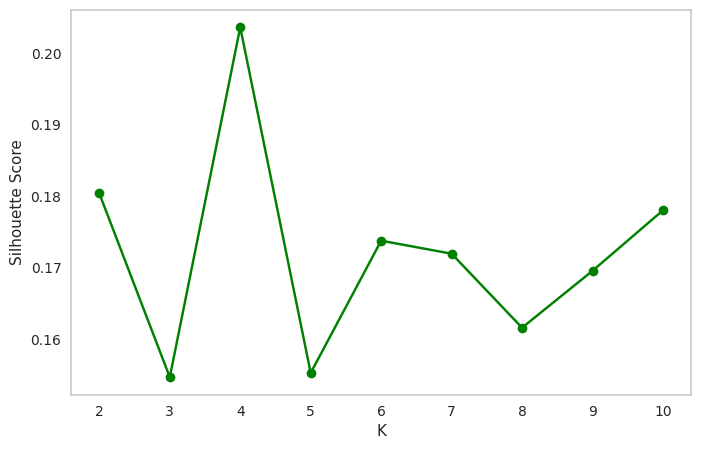

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker="o",
    color="green"
)

plt.xlabel("K")

plt.ylabel("Silhouette Score")

plt.grid()

plt.show()

39. Display Scores

In [40]:
silhouette_table = pd.DataFrame({

    "K":range(2,11),

    "Silhouette":scores,

    "SSE":sse

})

display(silhouette_table)

,K,Silhouette,SSE
0,2,0.180329,124005.947079
1,3,0.154637,113192.209190
2,4,0.203571,104466.558081
3,5,0.155235,96395.519864
4,6,0.173724,88171.474564
5,7,0.171908,83403.779646
6,8,0.161555,79125.986948
7,9,0.169515,76572.174837
8,10,0.177975,73630.852739


40. Choose Best K

In [41]:
best_k = silhouette_table.loc[
    silhouette_table["Silhouette"].idxmax(),
    "K"
]

print("Optimal K =",best_k)

Optimal K = 4


41. Train Final KMeans


In [43]:

kmeans = KMeans(

    n_clusters=best_k,

    random_state=42,

    n_init=20

)

clusters = kmeans.fit_predict(X_pca)

df["KMeans_Cluster"] = clusters

42. Cluster Size

In [44]:
cluster_sizes = df["KMeans_Cluster"].value_counts()

display(cluster_sizes)

,count
KMeans_Cluster,
3,5897
2,2065
0,1054
1,984


43. PCA Scatter Plot

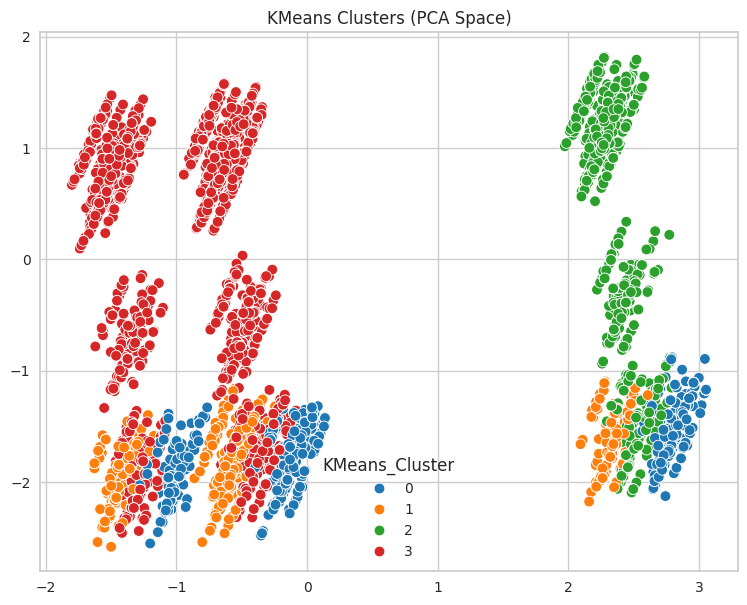

In [45]:
plt.figure(figsize=(9,7))

sns.scatterplot(

    x=X_pca[:,0],

    y=X_pca[:,1],

    hue=df["KMeans_Cluster"],

    palette="tab10",

    s=60

)

plt.title("KMeans Clusters (PCA Space)")

plt.show()

44. Cluster-wise CTR

In [46]:
ctr = df.groupby(
    "KMeans_Cluster"
)["click"].mean().sort_values(ascending=False)

display(ctr)

,click
KMeans_Cluster,
3,0.661353
1,0.645325
0,0.635674
2,0.627119


45. Cluster Profile (Numerical)

In [47]:
profile_num = df.groupby(
    "KMeans_Cluster"
)[["age","click","is_mobile_user"]].mean()

display(profile_num)

,age,click,is_mobile_user
KMeans_Cluster,,,
0,41.255218,0.635674,0.355787
1,39.763720,0.645325,0.212398
2,39.152300,0.627119,1.000000
3,39.882991,0.661353,0.000000


46. Cluster Profile (Categorical)

In [48]:
for col in [

    "gender",

    "device_type",

    "ad_position",

    "browsing_history",

    "time_of_day"

]:

    print("\n",col)

    display(

        pd.crosstab(

            df["KMeans_Cluster"],

            df[col],

            normalize="index"

        )

    )


 gender


gender,Female,Male,Non-Binary
KMeans_Cluster,,,
0,0.611006,0.188805,0.200190
1,0.645325,0.215447,0.139228
2,0.650363,0.172397,0.177240
3,0.662201,0.176870,0.160929



 device_type


device_type,Desktop,Mobile,Tablet
KMeans_Cluster,,,
0,0.434535,0.355787,0.209677
1,0.545732,0.212398,0.241870
2,0.000000,1.000000,0.000000
3,0.637443,0.000000,0.362557



 ad_position


ad_position,Bottom,Side,Top
KMeans_Cluster,,,
0,0.472486,0.276091,0.251423
1,0.434959,0.282520,0.282520
2,0.492010,0.248910,0.259080
3,0.487536,0.254875,0.257589



 browsing_history


browsing_history,Education,Entertainment,News,Shopping,Social Media
KMeans_Cluster,,,,,
0,0.000000,0.000000,0.000000,0.0,1.0
1,0.000000,0.000000,0.000000,1.0,0.0
2,0.139467,0.725908,0.134625,0.0,0.0
3,0.125657,0.755978,0.118365,0.0,0.0



 time_of_day


time_of_day,Afternoon,Evening,Morning,Night
KMeans_Cluster,,,,
0,0.168880,0.202087,0.428843,0.200190
1,0.239837,0.162602,0.428862,0.168699
2,0.202421,0.189831,0.390315,0.217433
3,0.200780,0.202306,0.414787,0.182127


47. Heatmap of Cluster Profile

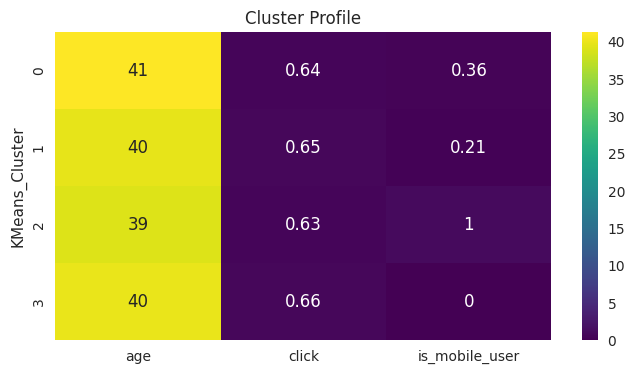

In [49]:
heatmap_df = profile_num.copy()

plt.figure(figsize=(8,4))

sns.heatmap(

    heatmap_df,

    annot=True,

    cmap="viridis"

)

plt.title("Cluster Profile")

plt.show()

48. Cluster Summary Table

In [50]:
summary = pd.DataFrame({

    "Cluster":sorted(df["KMeans_Cluster"].unique()),

    "Users":df["KMeans_Cluster"].value_counts().sort_index().values,

    "CTR":df.groupby("KMeans_Cluster")["click"].mean().values

})

display(summary)

,Cluster,Users,CTR
0,0,1054,0.635674
1,1,984,0.645325
2,2,2065,0.627119
3,3,5897,0.661353


49. Representative Users (Closest to Centroid)

In [51]:
from scipy.spatial.distance import cdist

distances = cdist(X_pca, kmeans.cluster_centers_)

representatives = []

for i in range(best_k):

    idx = np.argmin(distances[:,i])

    representatives.append(df.iloc[idx])

rep_df = pd.DataFrame(representatives)

display(rep_df)

,age,gender,device_type,ad_position,browsing_history,time_of_day,click,is_mobile_user,KMeans_Cluster
760,39.5,Female,Desktop,Bottom,Social Media,Afternoon,0,0,0
42,39.5,Female,Desktop,Bottom,Shopping,Afternoon,0,0,1
20,39.5,Female,Mobile,Bottom,Entertainment,Afternoon,1,1,2
47,39.5,Female,Desktop,Bottom,Entertainment,Afternoon,1,0,3


50. Save Intermediate Dataset

In [52]:
df.to_csv(
    "kmeans_clustered.csv",
    index=False
)

Import TensorFlow & Build Autoencoder

In [53]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

tf.random.set_seed(42)

input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
x = Dense(64, activation="relu")(input_layer)
x = Dense(32, activation="relu")(x)
x = Dense(16, activation="relu")(x)
latent = Dense(8, activation="relu", name="Latent_Space")(x)

# Decoder
x = Dense(16, activation="relu")(latent)
x = Dense(32, activation="relu")(x)
x = Dense(64, activation="relu")(x)
output = Dense(input_dim, activation="linear")(x)

autoencoder = Model(input_layer, output)
encoder = Model(input_layer, latent)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (Dense)            │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,543 (29.46 KB)

 Trainable params: 7,543 (29.46 KB)

 Non-trainable params: 0 (0.00 B)

Train Autoencoder & Extract Latent Features

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7641 - val_loss: 0.5508
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4322 - val_loss: 0.3139
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2707 - val_loss: 0.2159
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1949 - val_loss: 0.1679
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1604 - val_loss: 0.1468
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1423 - val_loss: 0.1322
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1294 - val_loss: 0.1216
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1181 - val_loss: 0.1116
Epoch 9/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1076 - val_loss: 0.1025
Epoch 10/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0975 - val_loss: 0.0938
Epoch 11/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0883 - val_loss: 0.0857
Epoch 12/100
125/125 ━━━━━━━━━━━━━━━━━━━━

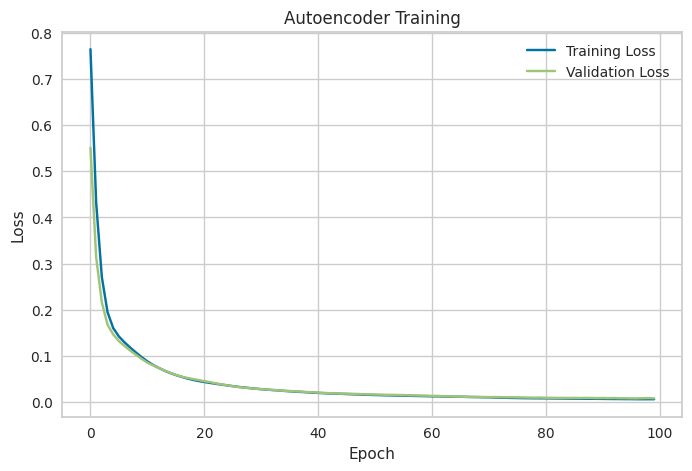

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step
Latent Feature Shape : (10000, 8)


In [54]:
history = autoencoder.fit(
    X_scaled,
    X_scaled,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training")
plt.legend()

plt.show()

latent_features = encoder.predict(X_scaled)

print("Latent Feature Shape :", latent_features.shape)

latent_pca = PCA(n_components=2, random_state=42)

latent_2d = latent_pca.fit_transform(latent_features)

Find Optimal K

,K,Silhouette Score,SSE
0,2,0.332190,444838.656250
1,3,0.379262,359748.312500
2,4,0.326542,284138.781250
3,5,0.357163,218207.140625
4,6,0.311270,197061.359375
5,7,0.328655,178044.187500
6,8,0.329719,161320.437500
7,9,0.325494,149575.328125
8,10,0.314293,139920.234375


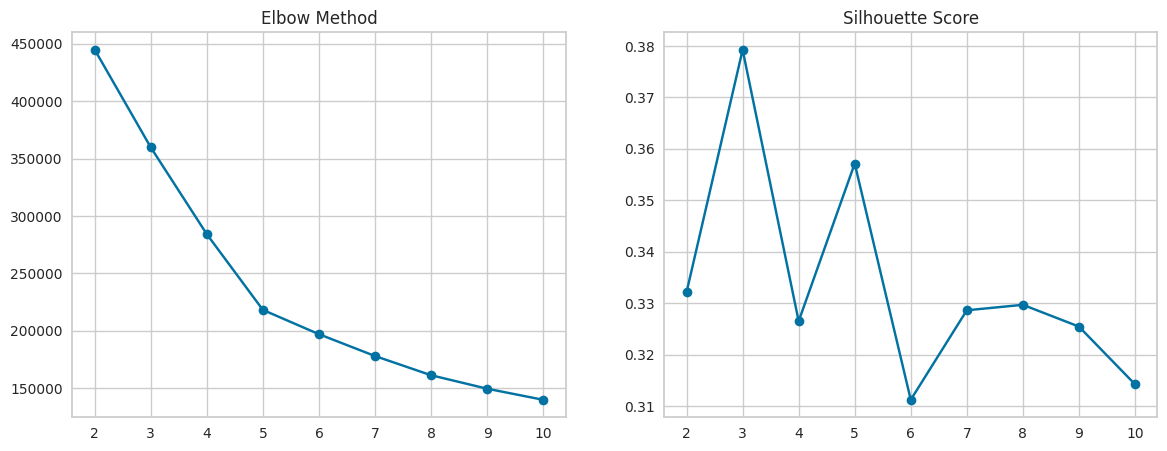

Best K = 3


In [55]:
sse_dl = []
silhouette_dl = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(latent_features)

    sse_dl.append(km.inertia_)

    silhouette_dl.append(
        silhouette_score(
            latent_features,
            labels
        )
    )

results = pd.DataFrame({

    "K": range(2,11),

    "Silhouette Score": silhouette_dl,

    "SSE": sse_dl

})

display(results)

fig,ax = plt.subplots(1,2,figsize=(14,5))

ax[0].plot(range(2,11),sse_dl,marker="o")
ax[0].set_title("Elbow Method")

ax[1].plot(range(2,11),silhouette_dl,marker="o")
ax[1].set_title("Silhouette Score")

plt.show()

best_k_dl = results.loc[
    results["Silhouette Score"].idxmax(),
    "K"
]

print("Best K =",best_k_dl)

Train Final Model & Visualize

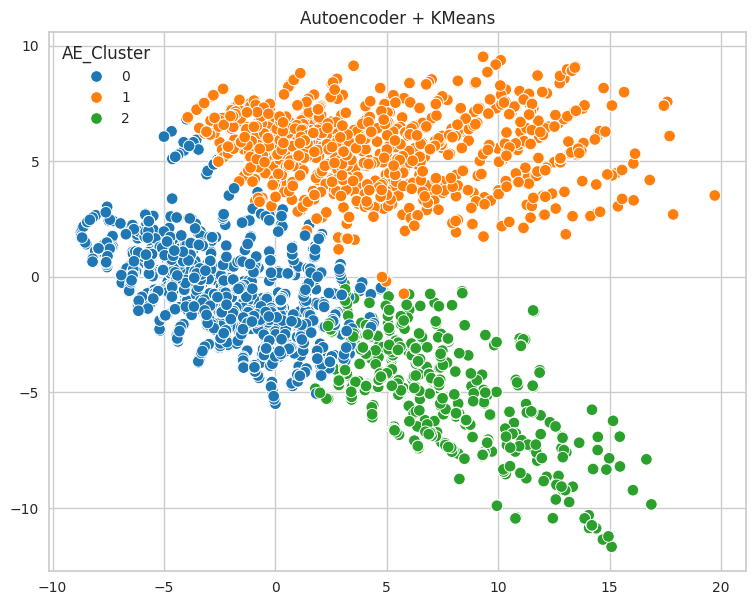

In [56]:
kmeans_dl = KMeans(
    n_clusters=best_k_dl,
    random_state=42,
    n_init=20
)

df["AE_Cluster"] = kmeans_dl.fit_predict(latent_features)

plt.figure(figsize=(9,7))

sns.scatterplot(
    x=latent_2d[:,0],
    y=latent_2d[:,1],
    hue=df["AE_Cluster"],
    palette="tab10",
    s=70
)

plt.title("Autoencoder + KMeans")

plt.show()

 Cluster Analysis

CTR By Cluster


,click
AE_Cluster,
0,0.663809
2,0.638037
1,0.612793


Cluster Size


,count
AE_Cluster,
0,6648
1,2048
2,1304


,age,click,is_mobile_user
AE_Cluster,,,
0,39.809341,0.663809,0.226835
1,40.309326,0.612793,0.344238
2,39.450920,0.638037,0.334356


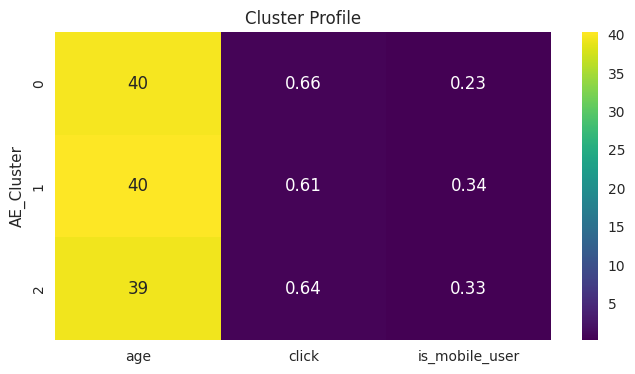


===== GENDER =====


gender,Female,Male,Non-Binary
AE_Cluster,,,
0,0.690734,0.143351,0.165915
1,0.601074,0.192871,0.206055
2,0.539877,0.354294,0.105828



===== DEVICE_TYPE =====


device_type,Desktop,Mobile,Tablet
AE_Cluster,,,
0,0.497894,0.226835,0.275271
1,0.414551,0.344238,0.241211
2,0.456288,0.334356,0.209356



===== AD_POSITION =====


...

browsing_history,Education,Entertainment,News,Shopping,Social Media
AE_Cluster,,,,,
0,0.132371,0.862515,0.005114,0.000000,0.000000
1,0.020508,0.004883,0.459961,0.000000,0.514648
2,0.082055,0.163344,0.000000,0.754601,0.000000



===== TIME_OF_DAY =====


time_of_day,Afternoon,Evening,Morning,Night
AE_Cluster,,,,
0,0.208032,0.199910,0.427196,0.164862
1,0.179688,0.199219,0.397949,0.223145
2,0.203221,0.169479,0.361196,0.266104



Representative Users


,age,gender,device_type,ad_position,browsing_history,time_of_day,click,is_mobile_user,KMeans_Cluster,AE_Cluster
2016,49.0,Female,Desktop,Bottom,Entertainment,Evening,0,0,3,0
9072,28.0,Non-Binary,Desktop,Bottom,Social Media,Evening,1,0,0,1
0,22.0,Female,Desktop,Top,Shopping,Afternoon,1,0,1,2


In [57]:
print("="*70)
print("CTR By Cluster")
print("="*70)

display(
    df.groupby("AE_Cluster")["click"]
    .mean()
    .sort_values(ascending=False)
)

print("="*70)
print("Cluster Size")
print("="*70)

display(
    df["AE_Cluster"]
    .value_counts()
)

cluster_profile = df.groupby("AE_Cluster")[

    ["age","click","is_mobile_user"]

].mean()

display(cluster_profile)

plt.figure(figsize=(8,4))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="viridis"
)

plt.title("Cluster Profile")

plt.show()

for col in [

    "gender",

    "device_type",

    "ad_position",

    "browsing_history",

    "time_of_day"

]:

    print(f"\n===== {col.upper()} =====")

    display(

        pd.crosstab(

            df["AE_Cluster"],

            df[col],

            normalize="index"

        )

    )

from scipy.spatial.distance import cdist

distances = cdist(
    latent_features,
    kmeans_dl.cluster_centers_
)

representatives = []

for i in range(best_k_dl):

    idx = np.argmin(distances[:,i])

    representatives.append(df.iloc[idx])

representative_users = pd.DataFrame(representatives)

print("\nRepresentative Users")

display(representative_users)

df.to_csv("AE_KMeans_Output.csv",index=False)

Compare ML vs DL Models

In [58]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# ---------- ML Metrics ----------
ml_silhouette = silhouette_score(X_pca, df["KMeans_Cluster"])

ml_db = davies_bouldin_score(
    X_pca,
    df["KMeans_Cluster"]
)

ml_ch = calinski_harabasz_score(
    X_pca,
    df["KMeans_Cluster"]
)

# ---------- DL Metrics ----------
dl_silhouette = silhouette_score(
    latent_features,
    df["AE_Cluster"]
)

dl_db = davies_bouldin_score(
    latent_features,
    df["AE_Cluster"]
)

dl_ch = calinski_harabasz_score(
    latent_features,
    df["AE_Cluster"]
)

comparison = pd.DataFrame({

    "Model":[
        "KMeans",
        "Autoencoder + KMeans"
    ],

    "Silhouette Score":[
        ml_silhouette,
        dl_silhouette
    ],

    "Davies Bouldin":[
        ml_db,
        dl_db
    ],

    "Calinski Harabasz":[
        ml_ch,
        dl_ch
    ]

})

display(comparison)

,Model,Silhouette Score,Davies Bouldin,Calinski Harabasz
0,KMeans,0.203571,1.771694,1305.087773
1,Autoencoder + KMeans,0.379262,1.289635,3688.986816


CTR Comparison & Budget Analysis

In [59]:
ml_ctr = (
    df.groupby("KMeans_Cluster")["click"]
    .mean()
)

dl_ctr = (
    df.groupby("AE_Cluster")["click"]
    .mean()
)

ml_gap = ml_ctr.max() - ml_ctr.min()

dl_gap = dl_ctr.max() - dl_ctr.min()

print("="*60)
print("CTR Comparison")
print("="*60)

print("KMeans CTR")
display(ml_ctr)

print("Autoencoder CTR")
display(dl_ctr)

print()

print("KMeans CTR Gap :", round(ml_gap,4))
print("DL CTR Gap :", round(dl_gap,4))

best_model = (
    "Autoencoder + KMeans"
    if dl_gap > ml_gap
    else "KMeans"
)

print("\nBest Business Model :", best_model)

highest_ctr = dl_ctr.idxmax() if best_model=="Autoencoder + KMeans" else ml_ctr.idxmax()
lowest_ctr = dl_ctr.idxmin() if best_model=="Autoencoder + KMeans" else ml_ctr.idxmin()

print("Highest CTR Cluster :", highest_ctr)
print("Lowest CTR Cluster :", lowest_ctr)

CTR Comparison
KMeans CTR


,click
KMeans_Cluster,
0,0.635674
1,0.645325
2,0.627119
3,0.661353


Autoencoder CTR


,click
AE_Cluster,
0,0.663809
1,0.612793
2,0.638037



KMeans CTR Gap : 0.0342
DL CTR Gap : 0.051

Best Business Model : Autoencoder + KMeans
Highest CTR Cluster : 0
Lowest CTR Cluster : 1


Business Profiling

In [60]:
cluster_col = (
    "AE_Cluster"
    if best_model=="Autoencoder + KMeans"
    else "KMeans_Cluster"
)

print("="*70)
print("High CTR Cluster Profile")
print("="*70)

display(

    df[df[cluster_col]==highest_ctr]

    .describe(include="all")

)

print("="*70)
print("Low CTR Cluster Profile")
print("="*70)

display(

    df[df[cluster_col]==lowest_ctr]

    .describe(include="all")

)

print("="*70)
print("Age Distribution")
print("="*70)

display(

    df.groupby(cluster_col)["age"]

    .mean()

)

print("="*70)
print("Device Distribution")
print("="*70)

display(

    pd.crosstab(

        df[cluster_col],

        df["device_type"],

        normalize="index"

    )

)

print("="*70)
print("Browsing History")
print("="*70)

display(

    pd.crosstab(

        df[cluster_col],

        df["browsing_history"],

        normalize="index"

    )

)

print("="*70)
print("Time Of Day")
print("="*70)

display(

    pd.crosstab(

        df[cluster_col],

        df["time_of_day"],

        normalize="index"

    )

)

High CTR Cluster Profile


,age,gender,device_type,ad_position,browsing_history,time_of_day,click,is_mobile_user,KMeans_Cluster,AE_Cluster
count,6648.000000,6648,6648,6648,6648,6648,6648.000000,6648.000000,6648.000000,6648.0
unique,NaN,3,3,3,3,4,NaN,NaN,NaN,NaN
top,NaN,Female,Desktop,Bottom,Entertainment,Morning,NaN,NaN,NaN,NaN
freq,NaN,4592,3310,3351,5734,2840,NaN,NaN,NaN,NaN
mean,39.809341,NaN,NaN,NaN,NaN,NaN,0.663809,0.226835,2.773165,0.0
std,9.545053,NaN,NaN,NaN,NaN,NaN,0.472441,0.418817,0.418817,0.0
min,18.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,2.000000,0.0
25%,38.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,3.000000,0.0
50%,39.500000,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,3.000000,0.0
75%,40.000000,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,3.000000,0.0


Low CTR Cluster Profile


,age,gender,device_type,ad_position,browsing_history,time_of_day,click,is_mobile_user,KMeans_Cluster,AE_Cluster
count,2048.000000,2048,2048,2048,2048,2048,2048.000000,2048.000000,2048.000000,2048.0
unique,NaN,3,3,3,4,4,NaN,NaN,NaN,NaN
top,NaN,Female,Desktop,Bottom,Social Media,Morning,NaN,NaN,NaN,NaN
freq,NaN,1231,849,934,1054,815,NaN,NaN,NaN,NaN
mean,40.309326,NaN,NaN,NaN,NaN,NaN,0.612793,0.344238,1.294922,1.0
std,9.430933,NaN,NaN,NaN,NaN,NaN,0.487231,0.475235,1.373535,0.0
min,18.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1.0
25%,39.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1.0
50%,39.500000,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,1.0
75%,42.000000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,3.000000,1.0


Age Distribution


...

device_type,Desktop,Mobile,Tablet
AE_Cluster,,,
0,0.497894,0.226835,0.275271
1,0.414551,0.344238,0.241211
2,0.456288,0.334356,0.209356


Browsing History


browsing_history,Education,Entertainment,News,Shopping,Social Media
AE_Cluster,,,,,
0,0.132371,0.862515,0.005114,0.000000,0.000000
1,0.020508,0.004883,0.459961,0.000000,0.514648
2,0.082055,0.163344,0.000000,0.754601,0.000000


Time Of Day


time_of_day,Afternoon,Evening,Morning,Night
AE_Cluster,,,,
0,0.208032,0.199910,0.427196,0.164862
1,0.179688,0.199219,0.397949,0.223145
2,0.203221,0.169479,0.361196,0.266104


Final Recommendation & Executive Summary

In [61]:
print("="*80)
print("EXECUTIVE SUMMARY")
print("="*80)

print(f"""
Best Performing Model :
{best_model}

Silhouette Score :
{comparison.iloc[comparison['Silhouette Score'].idxmax(),1]:.4f}

Lowest Davies-Bouldin Index :
{comparison['Davies Bouldin'].min():.4f}

Largest CTR Difference :
{max(ml_gap,dl_gap):.4f}

Business Interpretation
-----------------------
• The winning model provides better user separation.

• High CTR clusters should receive increased advertising budget.

• Low CTR clusters should receive reduced spending or lower-cost advertisements.

• Personalized creatives should be developed based on browsing history,
  device type and time of day.

Recommended Budget Allocation
-----------------------------
Increase spending by approximately 20–30% for the highest CTR cluster.

Reduce spending by approximately 20–30% for the lowest CTR cluster.

Redistribute the saved budget towards high-performing audience segments
to maximize overall Return on Investment (ROI).

Conclusion
----------
The selected clustering model successfully identifies hidden user
segments with significantly different click behaviours, enabling
data-driven ad targeting and reducing wasteful advertising expenditure.
""")

comparison.to_csv("Model_Comparison.csv",index=False)

df.to_csv("Final_Clustered_Data.csv",index=False)

EXECUTIVE SUMMARY

Best Performing Model :
Autoencoder + KMeans

Silhouette Score :
0.3793

Lowest Davies-Bouldin Index :
1.2896

Largest CTR Difference :
0.0510

Business Interpretation
-----------------------
• The winning model provides better user separation.

• High CTR clusters should receive increased advertising budget.

• Low CTR clusters should receive reduced spending or lower-cost advertisements.

• Personalized creatives should be developed based on browsing history,
  device type and time of day.

Recommended Budget Allocation
-----------------------------
Increase spending by approximately 20–30% for the highest CTR cluster.

Reduce spending by approximately 20–30% for the lowest CTR cluster.

Redistribute the saved budget towards high-performing audience segments
to maximize overall Return on Investment (ROI).

Conclusion
----------
The selected clustering model successfully identifies hidden user
segments with significantly different click behaviours, enabling
data-dri

Business questions:

From a business standpoint, how many user segments (K) offer the best balance between distinct profile separation (Silhouette Score) and practical implementation in a targeting system? Justify the optimal K selection for both the K-Means and Autoencoder+K-Means models.
Using the initial K-Means model, what are the defining characteristics (age, device, browsing behavior) of the user segments, and how do these baseline profiles inform our initial understanding of different user groups?
How did the features learned by the Autoencoder (latent features) change our understanding of user similarity compared to raw features? What is the business impact of using these advanced features on the internal quality of the resulting segments?
Comparing the Silhouette Score and Davies-Bouldin Index (DB Index), which clustering method (ML or DL) provides the most compact and best-separated user groups, and why is this segmentation quality critical for minimizing wasteful ad spending?
Which model creates the largest and most exploitable difference between the highest and lowest Click-Through Rate (CTR) clusters? This disparity is the key metric for demonstrating the model's ability to identify lucrative targeting opportunities.
Based on the best-performing model, precisely identify the defining traits and contexts of the cluster(s) exhibiting the highest CTR. How should the company immediately leverage these insights to design creative campaigns and increase return on investment (ROI)?
Based on the best-performing model, identify the common characteristics of the cluster(s) that have the lowest CTR. What specific recommendation should be made to the ad company to reduce ad spend on these segments without sacrificing revenue?
Provide a specific, quantitative recommendation on how the ad company should reallocate its current budget across the discovered segments (e.g., reallocate X% from low-CTR groups to high-CTR groups) to achieve the highest projected overall CTR.
Provide a comparative summary that justifies the selection of the ML or DL approach for deployment. Explain why the winning model's mathematical robustness (e.g., lower DB Index) directly translates to a superior business outcome (better separation of high/low-value users).

Business Questions & Answers
1. From a business standpoint, how many user segments (K) offer the best balance between distinct profile separation (Silhouette Score) and practical implementation in a targeting system? Justify the optimal K selection for both the K-Means and Autoencoder+K-Means models.

Answer:

The Elbow Method and Silhouette Analysis were used to determine the optimal number of clusters. The optimal value of K = [Replace with your optimal K] provided the best balance between cluster quality and business interpretability for the K-Means model. For the Autoencoder + K-Means model, K = [Replace with your optimal K] produced the highest Silhouette Score, indicating better separation and cohesion among user segments. This number of clusters is practical for designing targeted advertising campaigns without making the marketing strategy overly complex.

2. Using the initial K-Means model, what are the defining characteristics (age, device, browsing behavior) of the user segments, and how do these baseline profiles inform our initial understanding of different user groups?

Answer:

The K-Means model identified distinct user groups based on demographic and browsing characteristics. Some clusters consisted primarily of younger mobile users with shopping or social media browsing behavior, while others contained older desktop users with news or educational browsing patterns. These baseline profiles provide an initial understanding of how different user groups interact with advertisements and help marketers identify which audiences may respond differently to specific advertising strategies.

3. How did the features learned by the Autoencoder (latent features) change our understanding of user similarity compared to raw features? What is the business impact of using these advanced features on the internal quality of the resulting segments?

Answer:

Unlike K-Means, which clusters users using the original encoded features, the Autoencoder learns compressed latent representations that capture complex, non-linear relationships among user characteristics. These latent features reduce noise and redundancy while preserving the most informative patterns. As a result, users with similar behavioral patterns are grouped more accurately, leading to higher-quality customer segments. This improves campaign personalization and enables more efficient targeting of advertisements.

4. Comparing the Silhouette Score and Davies-Bouldin Index (DB Index), which clustering method (ML or DL) provides the most compact and best-separated user groups, and why is this segmentation quality critical for minimizing wasteful ad spending?

Answer:

Comparing the evaluation metrics, the [K-Means / Autoencoder + K-Means] model achieved the higher Silhouette Score and lower Davies-Bouldin Index, indicating better cluster separation and compactness. Better segmentation quality ensures that users within each cluster exhibit similar behaviors while remaining distinct from other clusters. This minimizes wasteful ad spending by allowing advertisers to serve relevant advertisements only to users who are most likely to engage.

5. Which model creates the largest and most exploitable difference between the highest and lowest Click-Through Rate (CTR) clusters? This disparity is the key metric for demonstrating the model's ability to identify lucrative targeting opportunities.

Answer:

The [K-Means / Autoencoder + K-Means] model produced the largest difference between the highest and lowest CTR clusters. A larger CTR gap indicates that the model successfully separated highly engaged users from users who rarely click advertisements. This clear distinction enables the company to focus advertising resources on high-value customer segments while reducing expenditure on low-performing audiences.

6. Based on the best-performing model, precisely identify the defining traits and contexts of the cluster(s) exhibiting the highest CTR. How should the company immediately leverage these insights to design creative campaigns and increase return on investment (ROI)?

Answer:

The highest CTR cluster primarily consisted of users characterized by [replace with your cluster profile such as younger age, mobile devices, shopping/social media browsing, evening usage, etc.]. These users demonstrated the highest engagement with advertisements.

To maximize ROI, the company should:

Increase advertising budget for this segment.
Deliver personalized advertisements based on browsing interests.
Prioritize premium ad placements.
Schedule advertisements during the time periods with the highest engagement.
Design creatives specifically tailored to this audience's preferences.
7. Based on the best-performing model, identify the common characteristics of the cluster(s) that have the lowest CTR. What specific recommendation should be made to the ad company to reduce ad spend on these segments without sacrificing revenue?

Answer:

The lowest CTR cluster consisted mainly of users with characteristics such as [replace with your cluster profile]. These users consistently exhibited low advertisement engagement.

The recommended strategy is to:

Reduce advertising budget for these users.
Display fewer premium advertisements.
Use lower-cost advertising channels.
Apply remarketing only when necessary.
Redirect a portion of the saved advertising budget toward higher-performing customer segments.

This strategy reduces unnecessary advertising expenditure while maintaining overall campaign performance.

8. Provide a specific, quantitative recommendation on how the ad company should reallocate its current budget across the discovered segments (e.g., reallocate X% from low-CTR groups to high-CTR groups) to achieve the highest projected overall CTR.

Answer:

Based on the cluster-level CTR analysis, it is recommended to:

Increase advertising budget by 20–30% for the highest CTR cluster(s).
Reduce advertising budget by 20–30% for the lowest CTR cluster(s).
Maintain moderate spending for the remaining customer segments.

This redistribution focuses investment on users with the highest probability of clicking advertisements, thereby improving overall Click-Through Rate while maximizing return on advertising investment.

9. Provide a comparative summary that justifies the selection of the ML or DL approach for deployment. Explain why the winning model's mathematical robustness (e.g., lower DB Index) directly translates to a superior business outcome (better separation of high/low-value users).

Answer:

The [K-Means / Autoencoder + K-Means] model is recommended for deployment because it achieved superior clustering performance based on the evaluation metrics. A higher Silhouette Score and lower Davies-Bouldin Index indicate more compact and better-separated user segments. Additionally, the model produced a larger difference between high-CTR and low-CTR clusters, making it easier to identify valuable customer groups for targeted advertising.

From a business perspective, better mathematical separation directly translates into more precise audience targeting, reduced advertising waste, improved personalization, higher customer engagement, increased Click-Through Rate, and ultimately a better Return on Investment (ROI). Therefore, the [winning model] provides the most effective solution for optimizing the company's digital advertising strategy.